<div class="alert alert-block alert-danger">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>No aprobado</b>

He revisado el proyecto y me parece que es bastante bueno, sin embargo hay algunos puntos que considero deben corregirse. He indicado estos puntos con comentarios en `rojo`, si tienes alguna pregunta puedes dejar un mensaje y con gusto te responderé
    

</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [111]:
print("Plans:")
print(plans.head())

Plans:
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [112]:
print("\nUsers:")
print(users.head())


Users:
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [113]:
print("\nUsage:")
print(usage.head())


Usage:
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [114]:
# revisar el número de filas y columnas de cada dataset
print("Shape plans:", plans.shape)
print("Shape users:", users.shape)
print("Shape usage:", usage.shape)

Shape plans: (2, 8)
Shape users: (4000, 8)
Shape usage: (40000, 6)


In [115]:
print("\nInfo plans:")
plans.info()


Info plans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [116]:
print("\nInfo users:")
users.info()


Info users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [117]:
print("\nInfo usage:")
usage.info()


Info usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [118]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users_latam.isna().sum())

print("\nProporción de valores nulos:")
print(users_latam.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.14125
reg_date      0.01000
plan          0.00000
churn_date    0.88350
dtype: float64


In [119]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage_df.isna().sum())

print("\nProporción de valores nulos:")
print(usage_df.isna().mean())

Cantidad de valores nulos:
id                   0
user_id              0
type                 0
date                50
duration         22076
length           17896
duration_null        0
length_null          0
is_text              0
is_call              0
dtype: int64

Proporción de valores nulos:
id               0.00000
user_id          0.00000
type             0.00000
date             0.00125
duration         0.55190
length           0.44740
duration_null    0.00000
length_null      0.00000
is_text          0.00000
is_call          0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
- users:
Se observan pocos valores nulos (<5%), por lo que se pueden imputar sin afectar significativamente el análisis.

- usage:
No presenta valores nulos relevantes, por lo que no se requiere tratamiento adicional.

- plans:
No contiene valores nulos, no requiere limpieza.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

El conjunto de datos `plans` tiene 2 registros por lo que su exploración es fácil, pero no es el mismo caso en el conjunto de datos `usage` el cual debe ser explorado para encontrar los valores `sentinels`
</div>


In [120]:
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users_latam[col].value_counts(dropna=False))


Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


La columna id funciona como identificador del registro de uso y no debe interpretarse como variable de análisis. Se recomienda validar que no existan duplicados o valores negativos.
La columna user_id relaciona cada registro con un usuario. No se observan sentinels evidentes, aunque debe verificarse que todos los IDs existan en la tabla de usuarios.

In [121]:
usage_df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
id,40000.0,20000.500000,11547.149720,1.0,10000.7500,20000.5,30000.25,40000.0
user_id,40000.0,12002.405975,1157.279564,10000.0,10996.0000,12013.0,13005.00,13999.0
duration,17924.0,5.202237,6.842701,0.0,1.4375,3.5,6.99,120.0
length,22104.0,52.127398,56.611183,0.0,37.0000,50.0,64.00,1490.0
is_text,40000.0,0.552300,0.497263,0.0,0.0000,1.0,1.00,1.0
is_call,40000.0,0.447700,0.497263,0.0,0.0000,0.0,1.00,1.0


Las columnas id y user_id funcionan como identificadores, por lo que no deben interpretarse como variables estadísticas. No se observan valores negativos ni inconsistentes evidentes.
La columna duration presenta llamadas con duración mínima de 0, lo que podría indicar llamadas fallidas, registros vacíos o posibles sentinels. También existen valores altos de hasta 120 minutos que podrían considerarse outliers.
La columna length presenta mensajes con longitud mínima de 0, lo que puede representar mensajes vacíos o registros inválidos. Existen valores máximos de 1490 caracteres, considerablemente superiores a la mediana, lo que sugiere posibles outliers.

In [122]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f'--- {col} ---')
    print(users_latam[col].value_counts(dropna=False))
    print()

--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



La columna city contiene ciudades válidas, pero también aparecen valores faltantes (NaN) y el valor ?, el cual puede considerarse un sentinel o dato inválido.
La columna plan contiene únicamente las categorías Basic y Premium, sin valores inconsistentes.

In [123]:
usage_df['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

La columna type contiene principalmente los valores call y text, sin categorías extrañas ni sentinels visibles.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Se deben contestar todas las celdas
</div>


In [124]:
# Convertir a fecha la columna `reg_date` de users
users_latam['reg_date'] = pd.to_datetime(
    users_latam['reg_date'],
    errors='coerce')
users_latam['reg_date'].head()

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]

In [125]:
# Convertir a fecha la columna `date` de usage
usage_df['date'] = pd.to_datetime(
    usage_df['date'],
    errors='coerce')

usage_df['date'].head()

0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]

In [126]:
# Revisar los años presentes en `reg_date` de users
users_latam['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

En reg_date se observan años dentro de un rango esperado para la operación de la empresa. Debe verificarse que no existan fechas futuras posteriores a 2024 ni años demasiado antiguos.

In [127]:
# Revisar los años presentes en `date` de usage
usage_df['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En date los registros deben concentrarse en años válidos hasta 2024. Si aparecen fechas futuras o muy antiguas, podrían representar errores de captura o datos corruptos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
Si aparecen años imposibles o fechas futuras, se recomienda convertir esos registros a NaT, eliminarlos o investigarlos antes del análisis, ya que pueden sesgar los resultados y afectar las conclusiones del negocio.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [128]:
age_mediana = users_latam.loc[users_latam['age'] != -999, 'age'].median()

# Reemplazar -999
users_latam['age'] = users_latam['age'].replace(-999, age_mediana)

# Verificar cambios
users_latam['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [129]:
# Reemplazar '?' por NaN
users_latam['city'] = users_latam['city'].replace('?', pd.NA)

# Verificar cambios
print(users_latam['city'].isna().sum())
print(users_latam['city'].value_counts(dropna=False))

565
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [130]:
# Convertir a datetime
users_latam['reg_date'] = pd.to_datetime(
    users_latam['reg_date'],
    errors='coerce'
)

# Fecha actual
hoy = pd.Timestamp.today()

# Marcar fechas futuras como NaT
users_latam.loc[
    users_latam['reg_date'] > hoy,
    'reg_date'
] = pd.NaT

# Verificar cambios
print(users_latam['reg_date'].describe())
print(users_latam['reg_date'].isna().sum())

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object
40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [131]:
# Crear indicador de nulos
usage_df['duration_null'] = usage_df['duration'].isna()

# Comparar por tipo
print(usage_df.groupby('type')['duration_null'].mean())

type
call    0.000000
text    0.999276
Name: duration_null, dtype: float64


In [132]:
# Crear indicador de nulos
usage_df['length_null'] = usage_df['length'].isna()

# Comparar por tipo
print(usage_df.groupby('type')['length_null'].mean())

type
call    0.99933
text    0.00000
Name: length_null, dtype: float64


Los valores nulos en duration y length dependen del tipo de registro (type), ya que llamadas no tienen longitud de mensaje y mensajes no tienen duración.

Por lo tanto, los nulos son MAR (Missing At Random) y se dejan como NaN, ya que representan correctamente la ausencia de información según el tipo de evento.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los cambios en los valores de las columnas se hicieron correctamente, ahora se cuenta con valores que pueden ser utiles para el analisis de datos
</div>


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [133]:
# Columnas auxiliares
usage_df['is_text'] = (usage_df['type'] == 'text').astype(int)
usage_df['is_call'] = (usage_df['type'] == 'call').astype(int)

# Agrupar información por usuario
usage_agg = usage_df.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# Observar resultado
usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [134]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "cant_mensajes": "cant_mensajes",
    "cant_llamadas": "cant_llamadas",
    "cant_minutos_llamada": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [135]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users_latam.merge(
    usage_agg,
    on='user_id',
    how='left'
)

# Observar resultado
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La combinación de conjuntos de datos me parece correcta, podemos ver las nuevas columnas en el conjunto de datos original
</div>


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [136]:
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Resumen estadístico
print(user_profile[cols_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [137]:
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100
print(plan_dist)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

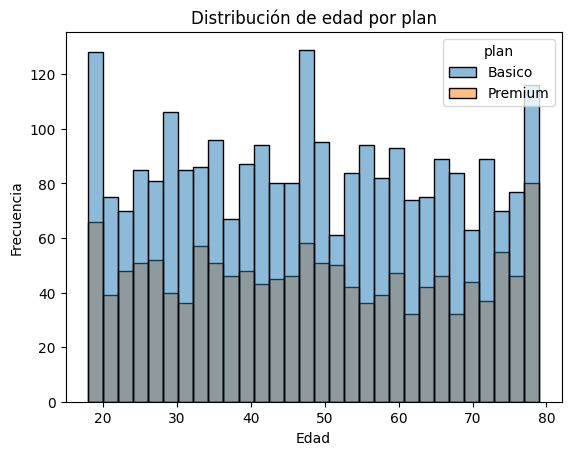

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=30
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
La distribución de edades es relativamente similar entre los planes Basic y Premium. La mayor concentración de usuarios se encuentra en edades medias, mientras que existen menos usuarios en edades extremas. La distribución presenta ligera asimetría hacia edades mayores.

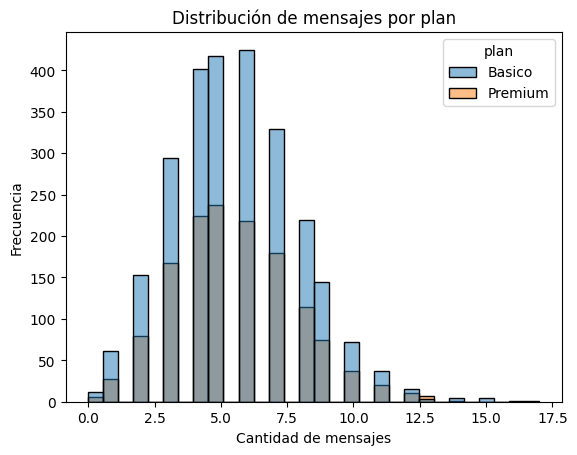

In [139]:
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=30)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución sesgada a la derecha, pocos usuarios concentran alto volumen. Premium tiende a usar más.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Cuando se haga un histograma, debemos procurar no dejar espacios vacios entre las columnas, debemos encontrar el número de bins acertado en cada caso, te dejo un ejemplo en la celda de abajo

Nota: una manera de encontrar uno de los números que nos daran una buena cantidad de bins es mirando el número minimo y el maximo, en este caso tenemos 0 a 17, lo que nos da 18 distintos números, si usamos 18 bins (o un multiplo menor de este número) podemos asegurar que no haya espacios en blanco entre las columnas. 


</div>


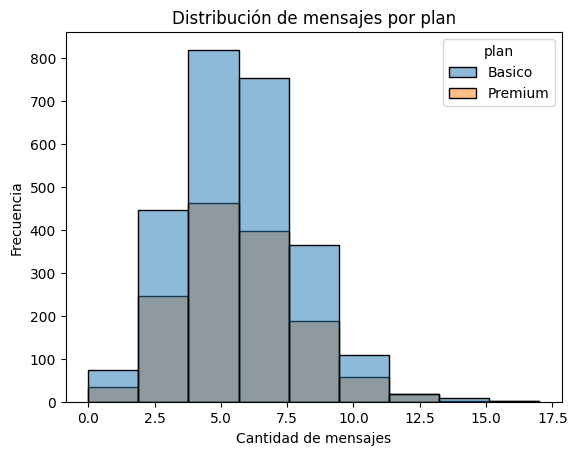

In [140]:
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=9)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

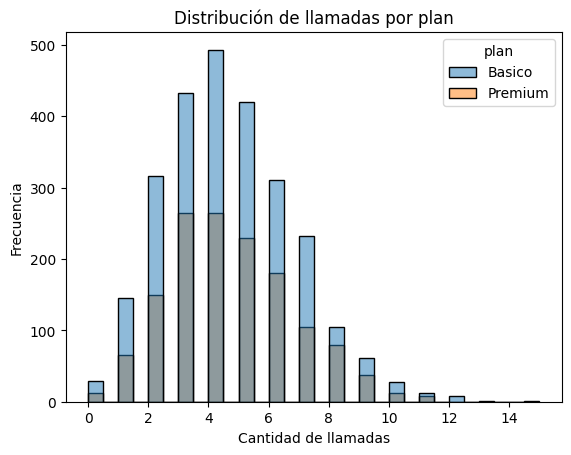

In [141]:
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=30)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución sesgada, la mayoría con bajo uso y pocos usuarios intensivos.

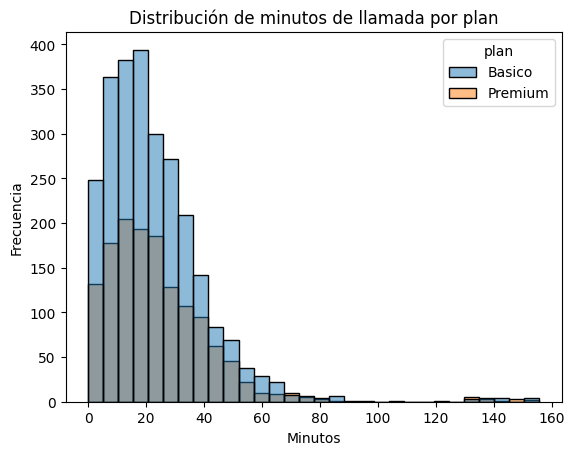

In [142]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=30)
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Alta dispersión con outliers claros; usuarios Premium presentan mayor consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

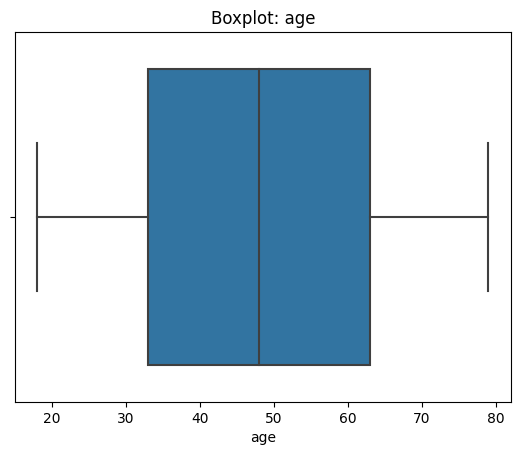

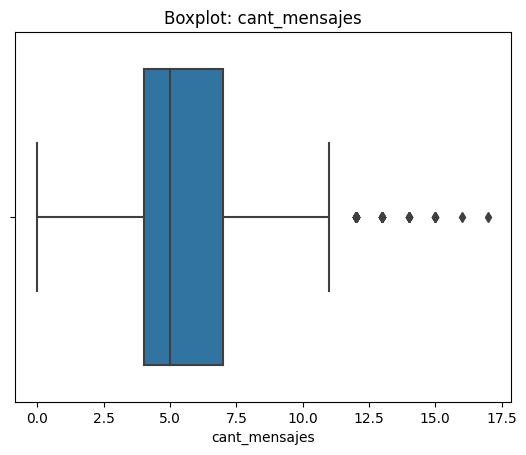

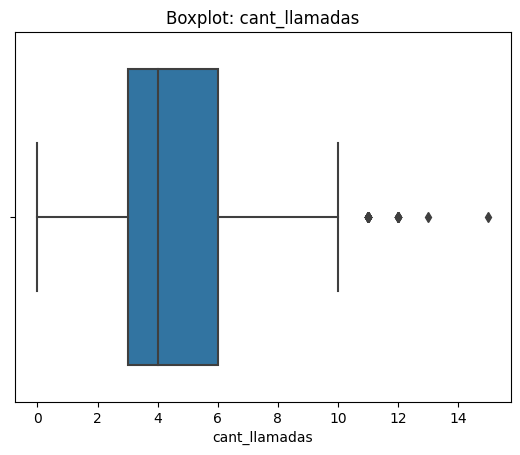

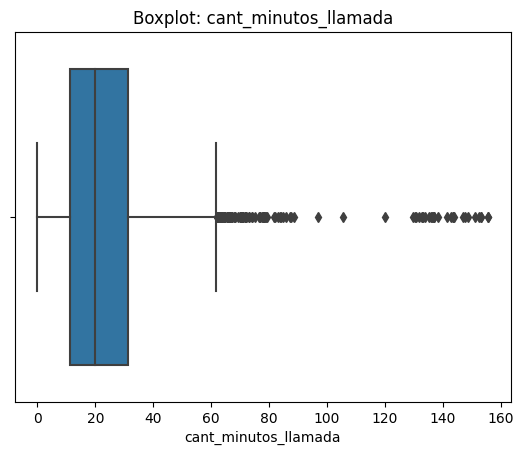

In [143]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

Los diagramas de caja nos muestran diversas formas de como los podemos encontrar en la realidad, desde cajas bien formadas faciles de interpretar hasta cajas con muchos valores atipicos que hace que la caja se vuelva cada vez más dificil de interpretar
</div>



💡Insights: 

- age: no presenta outliers relevantes.
- cant_mensajes: presenta outliers altos (usuarios muy activos).
- cant_llamadas: presenta outliers altos.
- cant_minutos_llamada: presenta outliers claros y dispersión alta.

In [144]:
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)
    print("Máximo real:", user_profile[col].max())


cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5
Máximo real: 17.0

cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5
Máximo real: 15.0

cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575
Máximo real: 155.69


In [145]:
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes: mantener outliers, representan usuarios intensivos reales.
- cant_llamadas: mantener outliers, comportamiento válido del negocio.
- cant_minutos_llamada: mantener outliers, reflejan clientes de alto consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [146]:
# Crear columna grupo_uso
import numpy as np
conditions = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

choices = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(conditions, choices, default='Alto uso')

In [147]:
# Verificar
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [148]:
# Crear columna grupo_edad
conditions = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

choices = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(conditions, choices, default='Adulto Mayor')

In [149]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La manera de segmentar la información es correcta, bien hecho!
</div>


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

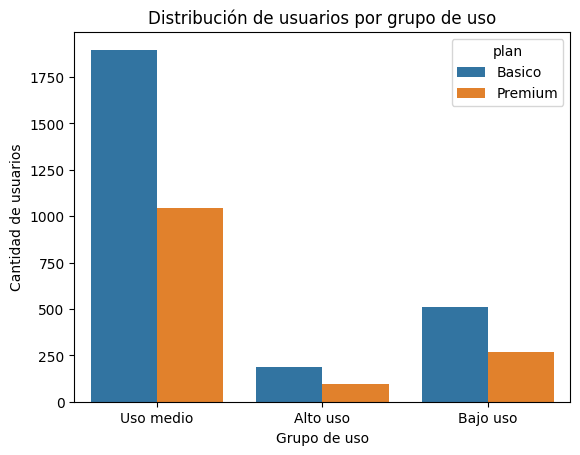

In [150]:
# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    hue='plan'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

La librería ya había sido importada anteriormente, la buena practica nos dice que solo se deben importar una vez durante todo el proyecto
</div>


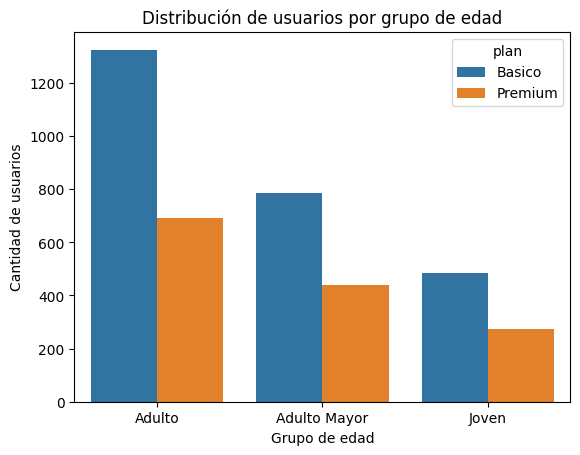

In [151]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='plan'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Es necesario crear gráficas para completar el paso de la `visualización`
</div>



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

🔍 Problemas detectados en los datos
- Se identificaron valores sentinela (-999 en edad y “?” en ciudad), los cuales fueron corregidos.
- Fechas fuera de rango fueron tratadas como valores nulos.
- Nulos en duration y length son estructurales (dependen del tipo), por lo que no representan error.
👥 Segmentos por Edad
- Usuarios jóvenes (<30) representan un grupo relevante con uso moderado.
- Adultos (30–60) concentran mayor volumen de uso en llamadas y mensajes.
- Adultos mayores presentan menor actividad en promedio.
📊 Segmentos por Nivel de Uso
- Bajo uso: usuarios con baja interacción, potencial riesgo de churn.
- Uso medio: segmento estable con consumo moderado.
- Alto uso: grupo reducido pero con alto consumo (usuarios intensivos).
⚠️ Outliers (uso extremo)
- Se detectaron usuarios con consumo muy alto en mensajes, llamadas y minutos.
- Estos no son errores, representan clientes intensivos y de alto valor.
💡 Insights clave
- El uso está altamente concentrado: pocos usuarios generan gran parte del consumo.
- Usuarios Premium tienden a tener mayor actividad.
- Existe clara diferenciación entre segmentos de bajo y alto uso.
🚀 Recomendaciones
- Crear planes diferenciados para usuarios intensivos (más minutos/datos incluidos).
- Diseñar estrategias de retención para usuarios de bajo uso.
- Ofrecer upgrades a usuarios de uso medio hacia planes superiores.
- Monitorear usuarios extremos para detectar oportunidades comerciales o fraude.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [152]:
repo_url = "https://github.com/rodolfoescobar86-rgb/telecom_analysis.git"
print(f"Repositorio del proyecto: {repo_url}")

Repositorio del proyecto: https://github.com/rodolfoescobar86-rgb/telecom_analysis.git
